# F1 Data Analytics 
## PARTE I: EDA + Algoritmos de Machine Learning
**Autor:** Gracia Nogales — Senior Advanced Support Engineer, Oracle  
**Datos:** FastF1 · Bahrain GP 2023 (Race)

---
### Estructura del notebook
| Sección | Contenido |
|---------|------------|
| 0 | Setup, imports y carga de datos |
| 1 | EDA — Exploración inicial del dataset |
| 2 | EDA — Análisis de tiempos de vuelta |
| 3 | EDA — Telemetría del coche |
| 4 | EDA — Estrategias de neumáticos |
| 5 | EDA — Correlaciones y heatmaps |
| 6 | ML — Clustering (K-Means + PCA) |
| 7 | ML — Regresión (predicción de tiempos) |
| 8 | ML — Clasificación (undercut detector) |
| 9 | ML — Detección de anomalías |


In [2]:
# ============================================================
# SECCIÓN 0: SETUP E IMPORTS
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Core
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               IsolationForest)
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, r2_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from scipy import stats
from scipy.stats import pearsonr, normaltest

# Config
fastf1.Cache.enable_cache('./f1_cache')
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

COLORS = {
    'primary':   '#E8002D',
    'secondary': '#00D2BE',
    'accent':    '#FF8700',
    'bg':        '#1a1a2e',
    'grid':      '#2a2a4e',
}
COMPOUND_COLORS = {
    'SOFT':         '#E8002D',
    'MEDIUM':       '#FFC906',
    'HARD':         '#EBEBEB',
    'INTERMEDIATE': '#39B54A',
    'WET':          '#0067FF',
}

print("=" * 65)
print("  F1 — EDA + MACHINE LEARNING")
print("  Setup completado OK")
print("=" * 65)

  F1 — EDA + MACHINE LEARNING
  Setup completado OK


In [3]:
# ============================================================
# SECCIÓN 0B: CARGA DE DATOS
# ============================================================

print("[1/3] Cargando Bahrain GP 2023 — Race...")
session = fastf1.get_session(2023, 'Bahrain', 'R')
session.load(telemetry=True, weather=True, messages=True)

laps    = session.laps.copy()
results = session.results.copy()
weather = session.weather_data.copy() if session.weather_data is not None else None

print(f"[2/3] Datos cargados:")
print(f"      Vueltas totales:  {len(laps):>5}")
print(f"      Pilotos:          {laps['Driver'].nunique():>5}")
print(f"      Columnas en laps: {len(laps.columns):>5}")

print("[3/3] Preprocess...")
laps['LapTimeS']  = laps['LapTime'].dt.total_seconds()
laps['Sector1S']  = laps['Sector1Time'].dt.total_seconds()
laps['Sector2S']  = laps['Sector2Time'].dt.total_seconds()
laps['Sector3S']  = laps['Sector3Time'].dt.total_seconds()

valid_laps = laps[
    laps['LapTimeS'].between(85, 130) &
    (laps['IsAccurate'] == True)
].copy()

top_drivers = (valid_laps.groupby('Driver')['LapTimeS']
               .median().sort_values().head(10).index.tolist())

print(f"      Vueltas válidas (filtradas): {len(valid_laps)}")
print(f"      Top 10 pilotos: {top_drivers}")
print("\nDataset listo OK")

[1/3] Cargando Bahrain GP 2023 — Race...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


[2/3] Datos cargados:
      Vueltas totales:   1056
      Pilotos:             20
      Columnas en laps:    31
[3/3] Preprocess...
      Vueltas válidas (filtradas): 914
      Top 10 pilotos: ['PER', 'VER', 'ALO', 'STR', 'BOT', 'GAS', 'TSU', 'ALB', 'RUS', 'SAI']

Dataset listo OK


---
## Sección 1 · EDA — Exploración Inicial del Dataset


1.1 Dimensiones del dataset:
    Filas: 1,056  |  Columnas: 35

1.2 Tipos de datos y valores nulos:
           Columna            Tipo  No Nulos  Nulos  %Nulos
              Time timedelta64[ns]      1056      0  0.0000
            Driver          object      1056      0  0.0000
      DriverNumber          object      1056      0  0.0000
           LapTime timedelta64[ns]      1055      1  0.1000
         LapNumber         float64      1056      0  0.0000
             Stint         float64      1056      0  0.0000
        PitOutTime timedelta64[ns]        50   1006 95.3000
         PitInTime timedelta64[ns]        52   1004 95.1000
       Sector1Time timedelta64[ns]      1035     21  2.0000
       Sector2Time timedelta64[ns]      1055      1  0.1000
       Sector3Time timedelta64[ns]      1055      1  0.1000
Sector1SessionTime timedelta64[ns]      1031     25  2.4000
Sector2SessionTime timedelta64[ns]      1055      1  0.1000
Sector3SessionTime timedelta64[ns]      1055      1  0.1000


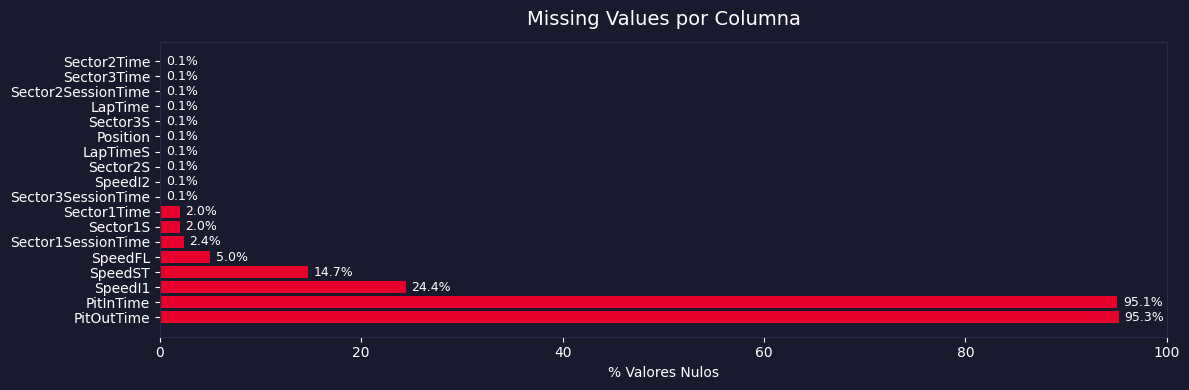


18 columnas con valores nulos de 23 numéricas


In [4]:
# ============================================================
# SECCIÓN 1: EDA — EXPLORACIÓN INICIAL
# ============================================================

print("1.1 Dimensiones del dataset:")
print(f"    Filas: {len(laps):,}  |  Columnas: {len(laps.columns)}")

print("\n1.2 Tipos de datos y valores nulos:")
dtype_df = pd.DataFrame({
    'Columna':  laps.dtypes.index,
    'Tipo':     laps.dtypes.values.astype(str),
    'No Nulos': laps.notna().sum().values,
    'Nulos':    laps.isna().sum().values,
    '%Nulos':   (laps.isna().mean() * 100).round(1).values,
})
print(dtype_df.to_string(index=False))

print("\n1.3 Primeras 5 vueltas (columnas clave):")
key_cols = ['Driver','LapNumber','LapTimeS','Sector1S','Sector2S','Sector3S',
            'Compound','TyreLife','Stint']
print(laps[key_cols].head().to_string(index=False))

print("\n1.4 Estadísticas descriptivas (vueltas válidas):")
desc_cols = ['LapTimeS','Sector1S','Sector2S','Sector3S','TyreLife']
print(valid_laps[desc_cols].describe().round(3))

# Missing values plot
numeric_cols = laps.select_dtypes(include=np.number).columns.tolist()
missing_pct  = (laps[numeric_cols].isna().mean() * 100).sort_values(ascending=False)
missing_pct  = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(12, 4), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=COLORS['primary'], edgecolor='none')
ax.bar_label(bars, fmt='%.1f%%', padding=4, color='white', fontsize=9)
ax.set_xlabel('% Valores Nulos', color='white')
ax.set_title('Missing Values por Columna', color='white', fontsize=14, pad=12)
ax.tick_params(colors='white')
ax.spines[:].set_color(COLORS['grid'])
plt.tight_layout()
plt.savefig('./eda_00_missing.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print(f"\n{len(missing_pct)} columnas con valores nulos de {len(numeric_cols)} numéricas")

---
## Sección 2 · EDA — Análisis de Tiempos de Vuelta


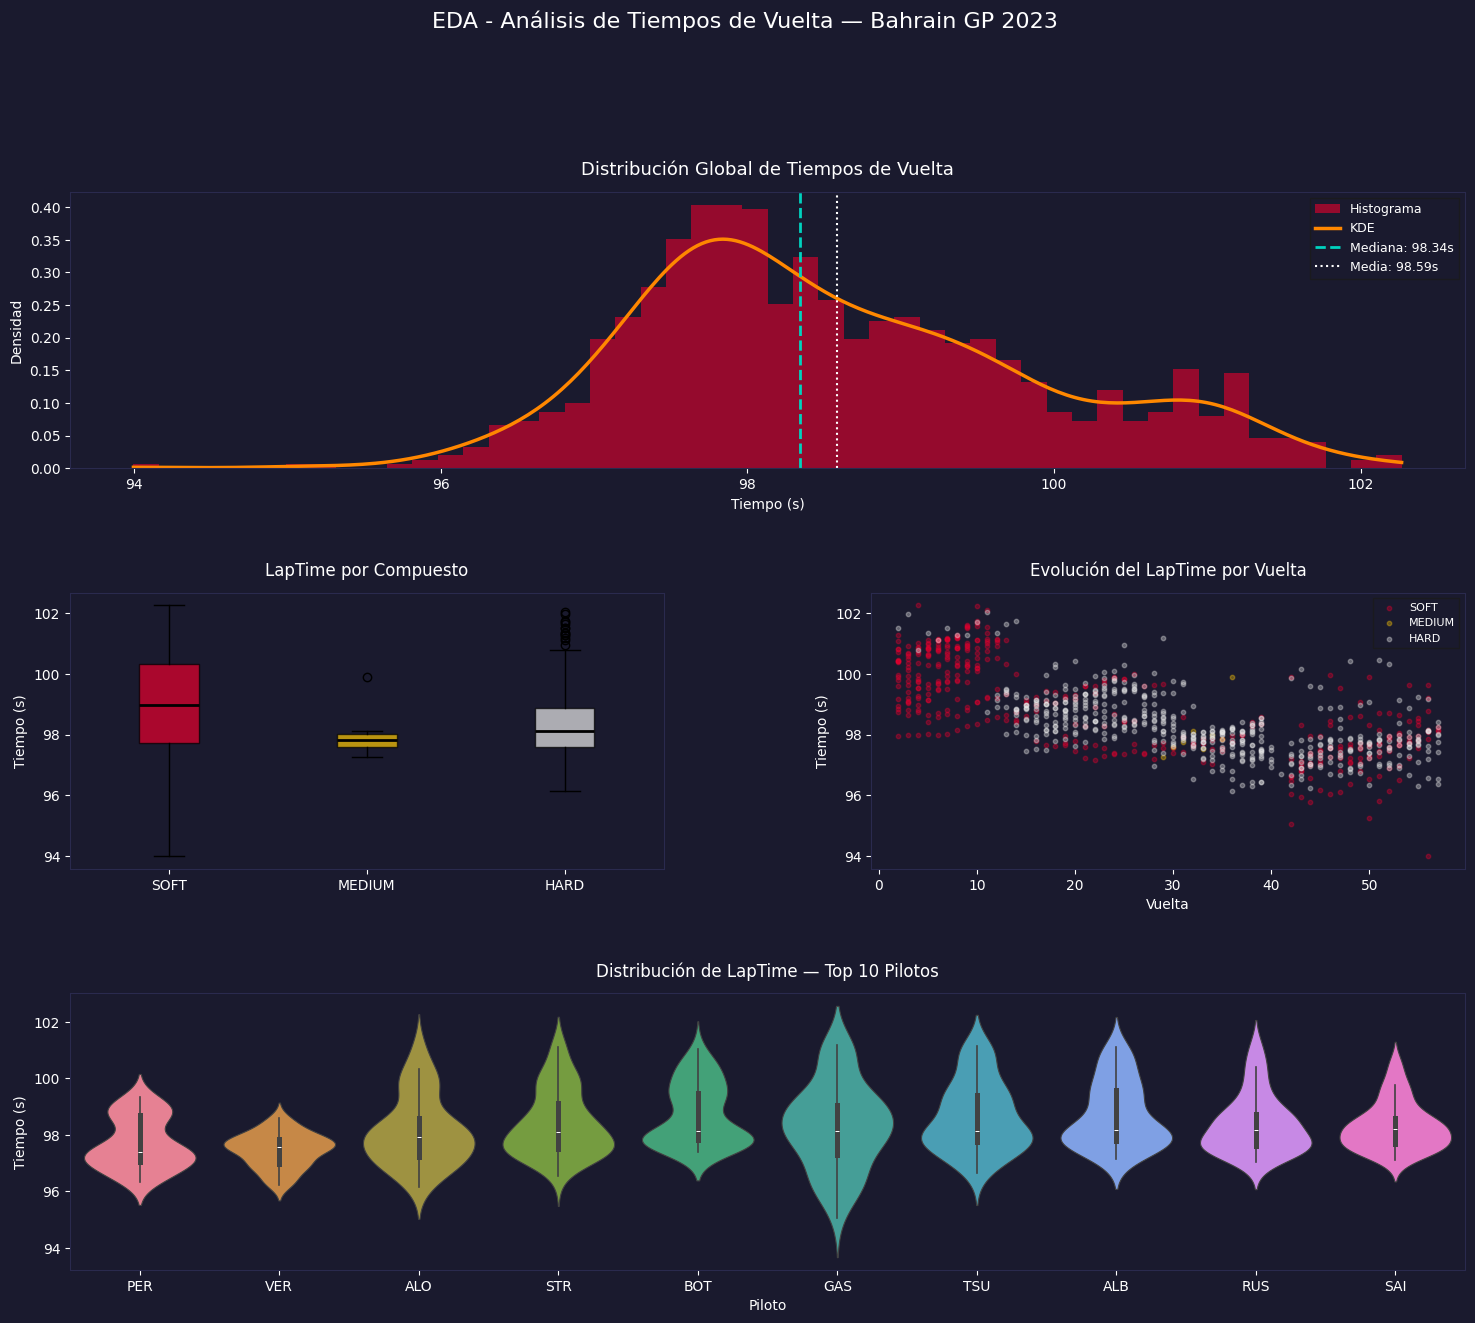


Estadísticas por compuesto:
          count    mean    std     min      max
Compound                                       
HARD        513 98.2760 1.0240 96.1560 102.0490
MEDIUM        8 98.0010 0.8080 97.2600  99.8860
SOFT        393 99.0040 1.5150 93.9960 102.2670


In [5]:
# ============================================================
# SECCIÓN 2: EDA — TIEMPOS DE VUELTA
# ============================================================

fig = plt.figure(figsize=(18, 14), facecolor=COLORS['bg'])
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# 2.1 Distribución global
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(COLORS['bg'])
data_lt = valid_laps['LapTimeS'].dropna()
ax1.hist(data_lt, bins=50, color=COLORS['primary'], alpha=0.6,
         edgecolor='none', density=True, label='Histograma')
kde_x = np.linspace(data_lt.min(), data_lt.max(), 300)
kde = gaussian_kde(data_lt)
ax1.plot(kde_x, kde(kde_x), color=COLORS['accent'], lw=2.5, label='KDE')
ax1.axvline(data_lt.median(), color=COLORS['secondary'], lw=2, ls='--',
            label=f"Mediana: {data_lt.median():.2f}s")
ax1.axvline(data_lt.mean(), color='white', lw=1.5, ls=':',
            label=f"Media: {data_lt.mean():.2f}s")
ax1.set_title('Distribución Global de Tiempos de Vuelta', color='white', fontsize=13)
ax1.set_xlabel('Tiempo (s)', color='white')
ax1.set_ylabel('Densidad', color='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_color(COLORS['grid'])
ax1.legend(facecolor=COLORS['bg'], labelcolor='white', fontsize=9)

# 2.2 Boxplot por compuesto
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(COLORS['bg'])
compounds = [c for c in ['SOFT','MEDIUM','HARD']
             if c in valid_laps['Compound'].unique()]
comp_data = [valid_laps[valid_laps['Compound'] == c]['LapTimeS'].dropna()
             for c in compounds]
bp = ax2.boxplot(comp_data, labels=compounds, patch_artist=True,
                 medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], compounds):
    patch.set_facecolor(COMPOUND_COLORS.get(c, '#888888'))
    patch.set_alpha(0.7)
ax2.set_title('LapTime por Compuesto', color='white', fontsize=12)
ax2.set_ylabel('Tiempo (s)', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color(COLORS['grid'])

# 2.3 Evolución por vuelta
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(COLORS['bg'])
for comp in compounds:
    sub = valid_laps[valid_laps['Compound'] == comp]
    ax3.scatter(sub['LapNumber'], sub['LapTimeS'],
                c=COMPOUND_COLORS.get(comp, '#888888'),
                alpha=0.35, s=10, label=comp)
ax3.set_title('Evolución del LapTime por Vuelta', color='white', fontsize=12)
ax3.set_xlabel('Vuelta', color='white')
ax3.set_ylabel('Tiempo (s)', color='white')
ax3.tick_params(colors='white')
ax3.spines[:].set_color(COLORS['grid'])
ax3.legend(facecolor=COLORS['bg'], labelcolor='white', fontsize=8)

# 2.4 Violin plot top pilotos
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor(COLORS['bg'])
top_data = valid_laps[valid_laps['Driver'].isin(top_drivers)]
palette   = sns.color_palette('husl', len(top_drivers))
sns.violinplot(data=top_data, x='Driver', y='LapTimeS',
               order=top_drivers, palette=palette,
               ax=ax4, inner='box', linewidth=0.8)
ax4.set_title('Distribución de LapTime — Top 10 Pilotos', color='white', fontsize=12)
ax4.set_xlabel('Piloto', color='white')
ax4.set_ylabel('Tiempo (s)', color='white')
ax4.tick_params(colors='white')
ax4.spines[:].set_color(COLORS['grid'])

fig.suptitle('EDA - Análisis de Tiempos de Vuelta — Bahrain GP 2023',
             color='white', fontsize=16, y=1.01)
plt.savefig('./eda_01_lap_times.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()

print("\nEstadísticas por compuesto:")
print(valid_laps.groupby('Compound')['LapTimeS']
      .agg(['count','mean','std','min','max']).round(3))

---
## Sección 3 · EDA — Telemetría del Coche


Telemetría: 1,086 puntos | Pilotos: ['PER' 'VER' 'ALO']

Estadísticas descriptivas de telemetría:
          Speed  Throttle        RPM     nGear       DRS
count 1086.0000 1086.0000  1086.0000 1086.0000 1086.0000
mean   199.5000   62.5300 10004.0500    5.1200    0.5500
std     66.7100   42.8600  1493.8500    1.7900    2.3800
min     58.0000    0.0000  4769.0000    2.0000    0.0000
25%    146.0000    1.0000  9412.2500    4.0000    0.0000
50%    207.0000   89.0000 10574.0000    5.0000    0.0000
75%    254.0000  100.0000 11013.7500    7.0000    0.0000
max    306.0000  100.0000 12161.0000    8.0000   14.0000


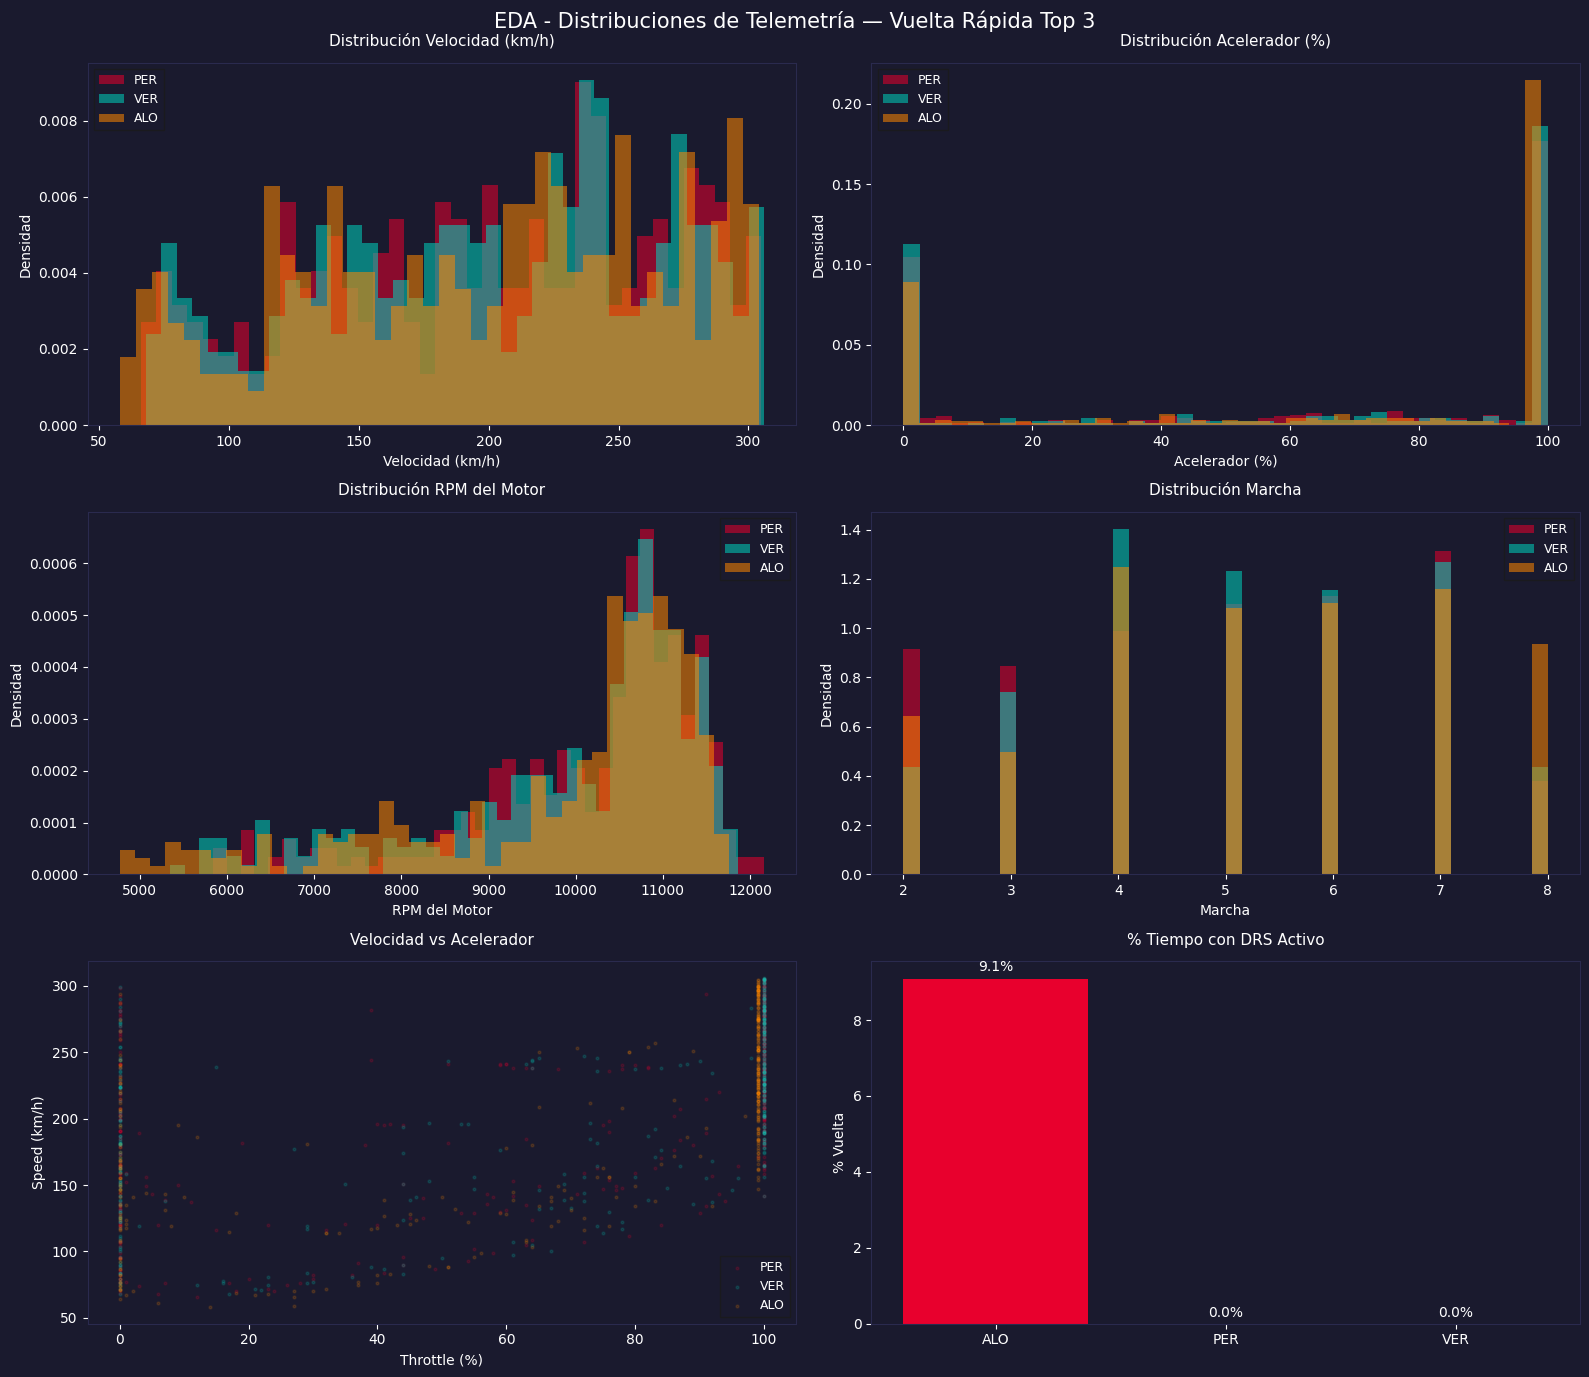

In [6]:
# ============================================================
# SECCIÓN 3: EDA — TELEMETRÍA
# ============================================================

top3 = (valid_laps.groupby('Driver')['LapTimeS']
        .median().sort_values().head(3).index.tolist())

tel_frames = []
for drv in top3:
    try:
        fastest = session.laps.pick_driver(drv).pick_fastest()
        t = fastest.get_car_data().add_distance()
        t['Driver'] = drv
        tel_frames.append(t)
    except Exception as e:
        print(f"  Warning {drv}: {e}")

tel_all = pd.concat(tel_frames, ignore_index=True) if tel_frames else pd.DataFrame()

if tel_all.empty:
    print("No se pudo cargar telemetría")
else:
    tel_num = [c for c in ['Speed','Throttle','Brake','RPM','nGear','DRS']
               if c in tel_all.columns]
    print(f"Telemetría: {len(tel_all):,} puntos | Pilotos: {tel_all['Driver'].unique()}")
    print("\nEstadísticas descriptivas de telemetría:")
    print(tel_all[tel_num].describe().round(2))

    drv_colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]
    fig, axes = plt.subplots(3, 2, figsize=(16, 14), facecolor=COLORS['bg'])
    fig.suptitle('EDA - Distribuciones de Telemetría — Vuelta Rápida Top 3',
                 color='white', fontsize=15)

    plot_vars = [
        ('Speed',    'Velocidad (km/h)'),
        ('Throttle', 'Acelerador (%)'),
        ('RPM',      'RPM del Motor'),
        ('nGear',    'Marcha'),
    ]
    for idx, (var, label) in enumerate(plot_vars):
        if var not in tel_all.columns:
            continue
        ax = axes[idx // 2][idx % 2]
        ax.set_facecolor(COLORS['bg'])
        for i, drv in enumerate(top3):
            sub = tel_all[tel_all['Driver'] == drv][var].dropna()
            ax.hist(sub, bins=40, alpha=0.55, color=drv_colors[i],
                    label=drv, density=True, edgecolor='none')
        ax.set_title(f'Distribución {label}', color='white', fontsize=11)
        ax.set_xlabel(label, color='white')
        ax.set_ylabel('Densidad', color='white')
        ax.tick_params(colors='white')
        ax.spines[:].set_color(COLORS['grid'])
        ax.legend(facecolor=COLORS['bg'], labelcolor='white', fontsize=9)

    # Scatter Speed vs Throttle
    ax_s = axes[2][0]
    ax_s.set_facecolor(COLORS['bg'])
    for i, drv in enumerate(top3):
        sub = tel_all[tel_all['Driver'] == drv]
        if 'Throttle' in sub.columns and 'Speed' in sub.columns:
            ax_s.scatter(sub['Throttle'], sub['Speed'],
                         alpha=0.15, s=4, color=drv_colors[i], label=drv)
    ax_s.set_title('Velocidad vs Acelerador', color='white', fontsize=11)
    ax_s.set_xlabel('Throttle (%)', color='white')
    ax_s.set_ylabel('Speed (km/h)', color='white')
    ax_s.tick_params(colors='white')
    ax_s.spines[:].set_color(COLORS['grid'])
    ax_s.legend(facecolor=COLORS['bg'], labelcolor='white', fontsize=9)

    # DRS usage
    ax_d = axes[2][1]
    ax_d.set_facecolor(COLORS['bg'])
    if 'DRS' in tel_all.columns:
        drs_usage = (tel_all.groupby('Driver')['DRS']
                     .apply(lambda x: (x > 8).mean() * 100)
                     .reset_index(name='DRS_pct'))
        bars = ax_d.bar(drs_usage['Driver'], drs_usage['DRS_pct'],
                        color=drv_colors[:len(drs_usage)], edgecolor='none')
        ax_d.bar_label(bars, fmt='%.1f%%', padding=3, color='white', fontsize=10)
        ax_d.set_title('% Tiempo con DRS Activo', color='white', fontsize=11)
        ax_d.set_ylabel('% Vuelta', color='white')
        ax_d.tick_params(colors='white')
        ax_d.spines[:].set_color(COLORS['grid'])

    plt.tight_layout()
    plt.savefig('./eda_02_telemetry.png', dpi=150, bbox_inches='tight',
                facecolor=COLORS['bg'])
    plt.show()

---
## Sección 4 · EDA — Estrategias de Neumáticos


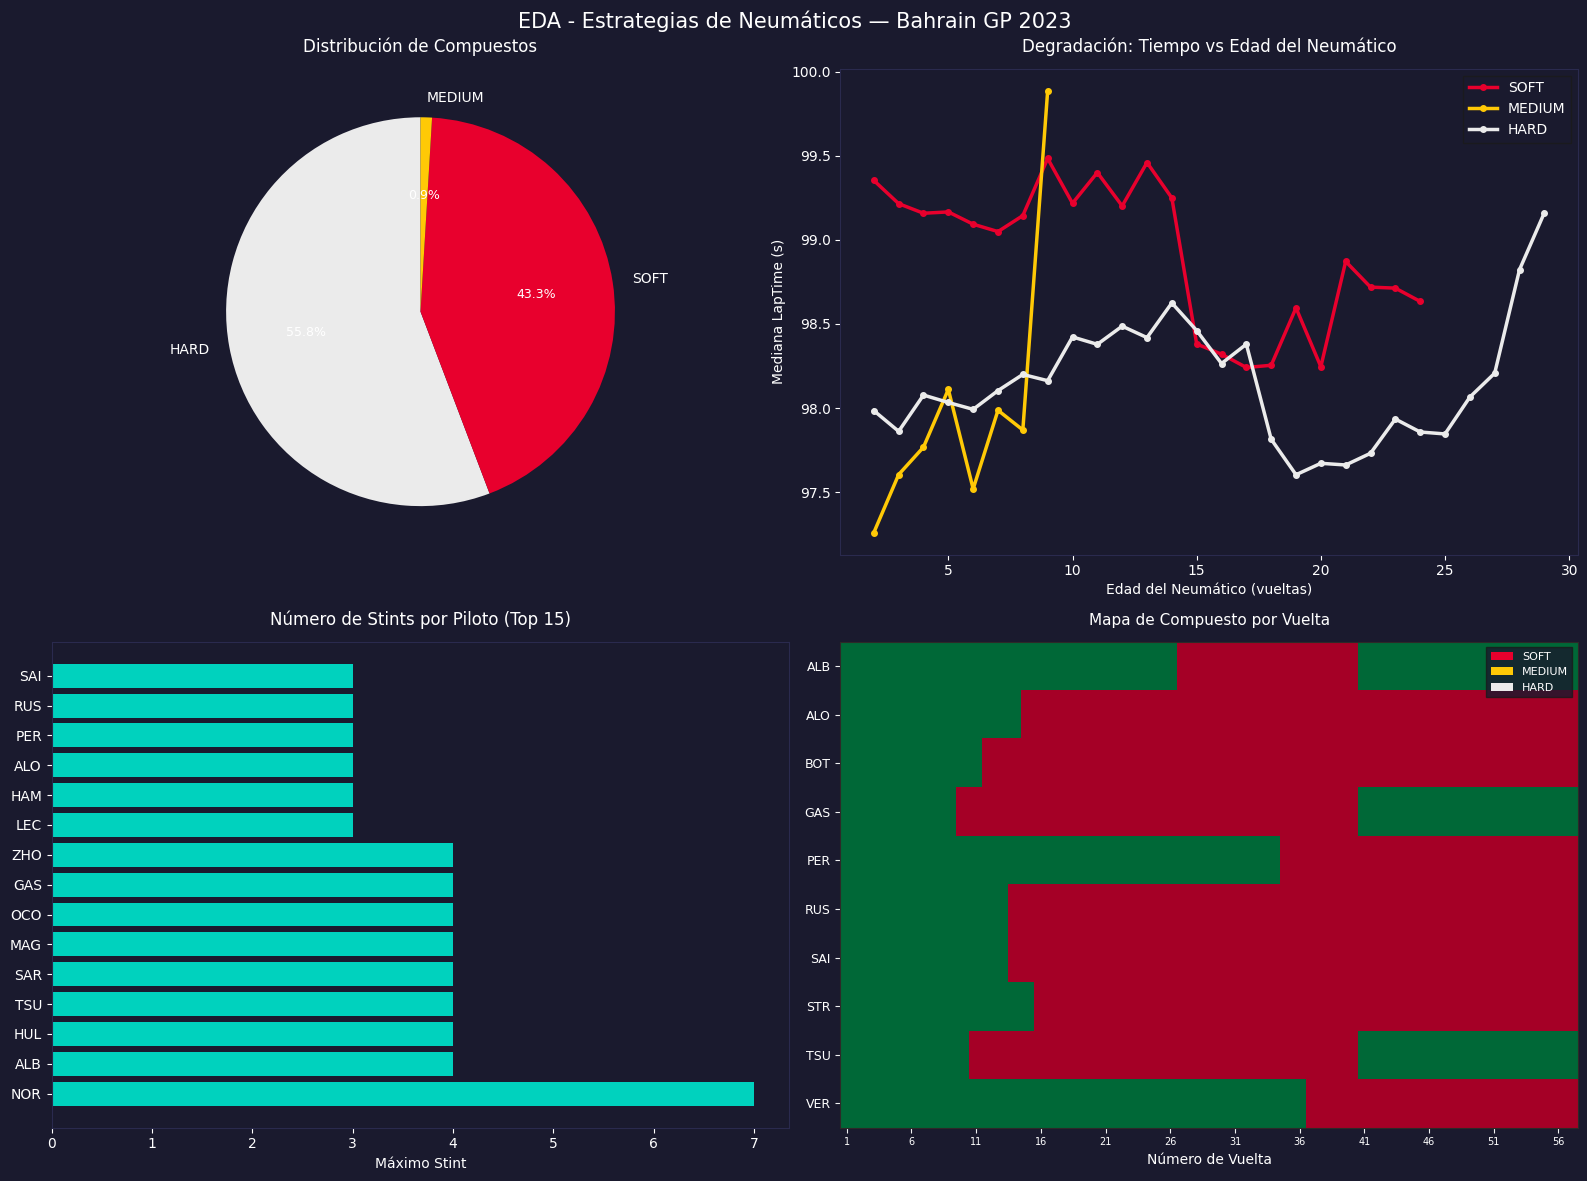


Degradación media (pendiente lineal):
  SOFT      : -0.0175s/vuelta  (R=-0.053)
  MEDIUM    : +0.2354s/vuelta  (R=0.713)
  HARD      : +0.0015s/vuelta  (R=0.009)


In [7]:
# ============================================================
# SECCIÓN 4: EDA — ESTRATEGIAS DE NEUMÁTICOS
# ============================================================

from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=COLORS['bg'])
fig.suptitle('EDA - Estrategias de Neumáticos — Bahrain GP 2023',
             color='white', fontsize=15)

# 4.1 Distribución de compuestos
ax1 = axes[0][0]
ax1.set_facecolor(COLORS['bg'])
comp_counts = laps['Compound'].value_counts()
colors_list = [COMPOUND_COLORS.get(c, '#888888') for c in comp_counts.index]
wedges, texts, autotexts = ax1.pie(
    comp_counts.values, labels=comp_counts.index,
    colors=colors_list, autopct='%1.1f%%',
    textprops={'color': 'white'}, startangle=90)
for at in autotexts:
    at.set_fontsize(9)
ax1.set_title('Distribución de Compuestos', color='white', fontsize=12)

# 4.2 Degradación: LapTime vs TyreLife
ax2 = axes[0][1]
ax2.set_facecolor(COLORS['bg'])
for comp in ['SOFT','MEDIUM','HARD']:
    sub = valid_laps[valid_laps['Compound'] == comp]
    if sub.empty:
        continue
    grp = sub.groupby('TyreLife')['LapTimeS'].median().reset_index()
    ax2.plot(grp['TyreLife'], grp['LapTimeS'],
             color=COMPOUND_COLORS.get(comp, '#888888'),
             lw=2.5, marker='o', ms=4, label=comp)
ax2.set_title('Degradación: Tiempo vs Edad del Neumático', color='white', fontsize=12)
ax2.set_xlabel('Edad del Neumático (vueltas)', color='white')
ax2.set_ylabel('Mediana LapTime (s)', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color(COLORS['grid'])
ax2.legend(facecolor=COLORS['bg'], labelcolor='white')

# 4.3 Stints por piloto
ax3 = axes[1][0]
ax3.set_facecolor(COLORS['bg'])
stints_per_driver = (laps.groupby('Driver')['Stint']
                     .max().sort_values(ascending=False).head(15))
ax3.barh(stints_per_driver.index, stints_per_driver.values,
         color=COLORS['secondary'], edgecolor='none')
ax3.set_title('Número de Stints por Piloto (Top 15)', color='white', fontsize=12)
ax3.set_xlabel('Máximo Stint', color='white')
ax3.tick_params(colors='white')
ax3.spines[:].set_color(COLORS['grid'])

# 4.4 Heatmap compuesto por vuelta
ax4 = axes[1][1]
ax4.set_facecolor(COLORS['bg'])
pivot_comp = (laps[laps['Driver'].isin(top_drivers)]
              .pivot_table(index='Driver', columns='LapNumber',
                           values='Compound', aggfunc='first'))
comp_map = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4}
pivot_num = pivot_comp.map(lambda x: comp_map.get(x, np.nan) if pd.notna(x) else np.nan)
ax4.imshow(pivot_num.values, aspect='auto', cmap='RdYlGn_r', interpolation='nearest')
ax4.set_xticks(range(0, pivot_num.shape[1], 5))
ax4.set_xticklabels(range(1, pivot_num.shape[1]+1, 5), color='white', fontsize=7)
ax4.set_yticks(range(len(pivot_num.index)))
ax4.set_yticklabels(pivot_num.index, color='white', fontsize=9)
ax4.set_title('Mapa de Compuesto por Vuelta', color='white', fontsize=11)
ax4.set_xlabel('Número de Vuelta', color='white')
legend_elements = [Patch(facecolor=COMPOUND_COLORS[k], label=k)
                   for k in ['SOFT','MEDIUM','HARD']]
ax4.legend(handles=legend_elements, loc='upper right',
           facecolor=COLORS['bg'], labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('./eda_03_tyres.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()

print("\nDegradación media (pendiente lineal):")
for comp in ['SOFT','MEDIUM','HARD']:
    sub = valid_laps[valid_laps['Compound'] == comp].dropna(subset=['TyreLife','LapTimeS'])
    if len(sub) < 5:
        continue
    slope, _, r, _, _ = stats.linregress(sub['TyreLife'], sub['LapTimeS'])
    print(f"  {comp:10s}: {slope:+.4f}s/vuelta  (R={r:.3f})")

---
## Sección 5 · EDA — Correlaciones y Análisis Estadístico


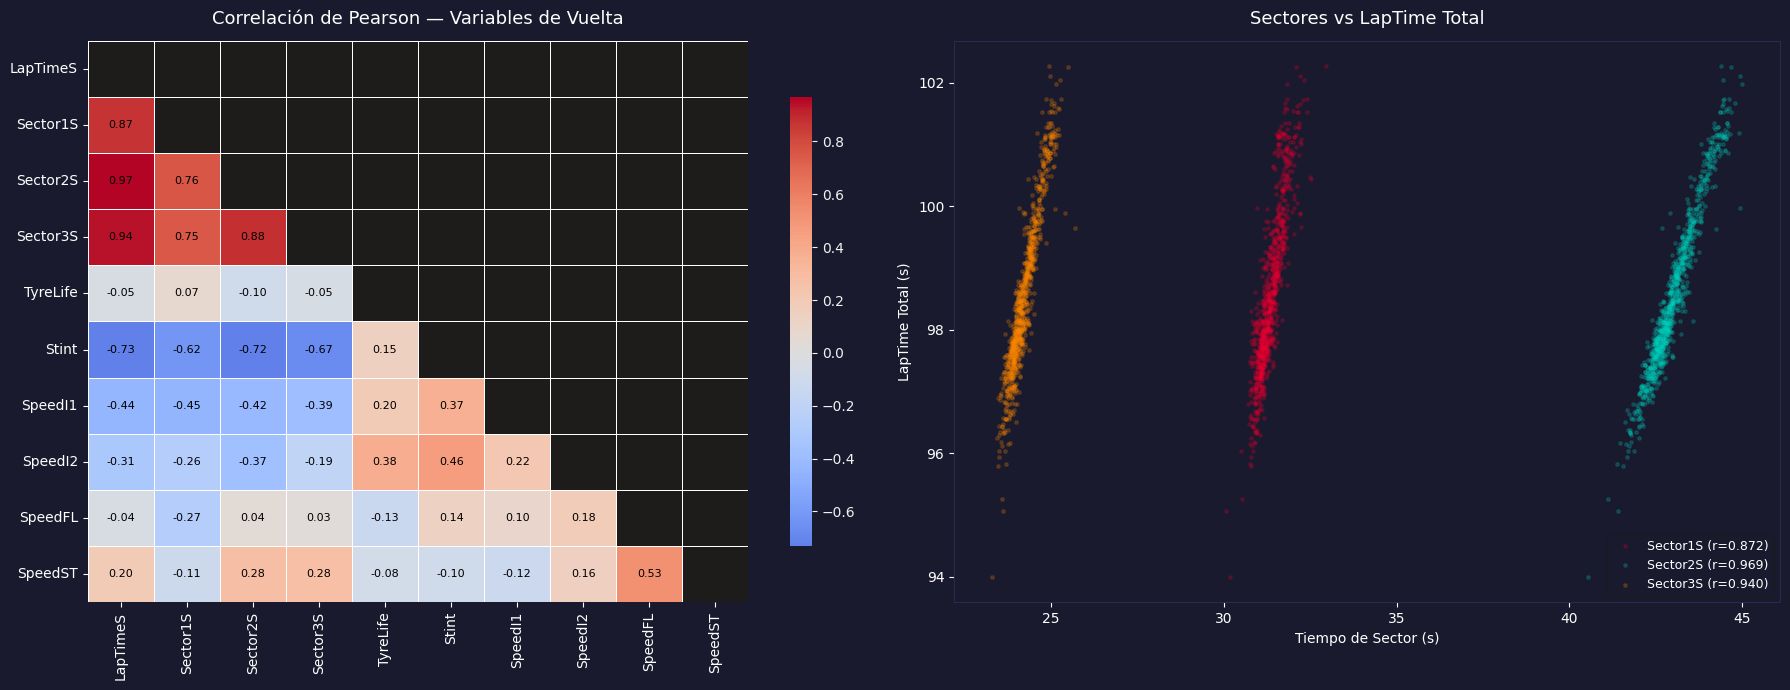


Test de normalidad D'Agostino-Pearson en LapTimeS:
  Estadístico: 32.3759  |  p-value: 9.33e-08
  No sigue distribucion normal (p<0.05)

Correlaciones con LapTimeS:
  Sector1S       : r = +0.8717  ***
  Sector2S       : r = +0.9687  ***
  Sector3S       : r = +0.9396  ***
  TyreLife       : r = -0.0470  
  Stint          : r = -0.7311  ***
  SpeedI1        : r = -0.4431  ***
  SpeedI2        : r = -0.3139  ***
  SpeedFL        : r = -0.0379  
  SpeedST        : r = +0.1962  ***


In [8]:
# ============================================================
# SECCIÓN 5: EDA — CORRELACIONES Y HEATMAPS
# ============================================================

corr_cols_candidate = ['LapTimeS','Sector1S','Sector2S','Sector3S',
                        'TyreLife','Stint','SpeedI1','SpeedI2',
                        'SpeedFL','SpeedST']
available = [c for c in corr_cols_candidate if c in valid_laps.columns]
corr_matrix = valid_laps[available].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=COLORS['bg'])

# Heatmap
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax1, mask=mask,
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8, 'color': 'black'},
            cbar_kws={'shrink': 0.8})
ax1.set_title('Correlación de Pearson — Variables de Vuelta',
              color='white', fontsize=13, pad=12)
ax1.tick_params(colors='white')

# Scatter sectores vs laptime
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg'])
sec_cols = [c for c in ['Sector1S','Sector2S','Sector3S'] if c in valid_laps.columns]
sec_clrs = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]
for sec, col in zip(sec_cols, sec_clrs):
    sub = valid_laps[[sec, 'LapTimeS']].dropna()
    r_val, _ = pearsonr(sub[sec], sub['LapTimeS'])
    ax2.scatter(sub[sec], sub['LapTimeS'],
                alpha=0.2, s=6, color=col,
                label=f'{sec} (r={r_val:.3f})')
ax2.set_title('Sectores vs LapTime Total', color='white', fontsize=13)
ax2.set_xlabel('Tiempo de Sector (s)', color='white')
ax2.set_ylabel('LapTime Total (s)', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color(COLORS['grid'])
ax2.legend(facecolor=COLORS['bg'], labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('./eda_04_correlations.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()

# Test de normalidad
stat, p = normaltest(valid_laps['LapTimeS'].dropna())
print(f"\nTest de normalidad D'Agostino-Pearson en LapTimeS:")
print(f"  Estadístico: {stat:.4f}  |  p-value: {p:.2e}")
print(f"  {'No sigue distribucion normal (p<0.05)' if p < 0.05 else 'No se rechaza normalidad'}")

print("\nCorrelaciones con LapTimeS:")
for col in available:
    if col == 'LapTimeS':
        continue
    sub = valid_laps[[col, 'LapTimeS']].dropna()
    if len(sub) < 10:
        continue
    r_val, p_val = pearsonr(sub[col], sub['LapTimeS'])
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f"  {col:15s}: r = {r_val:+.4f}  {sig}")

---
## Sección 6 · Algoritmos — Clustering de Estilos de Conducción
**Objetivo:** Agrupar pilotos por perfil de conducción usando K-Means + PCA.


Preparando features para clustering por piloto...
PCA varianza explicada: PC1=29.0%, PC2=27.7%, Total=56.7%


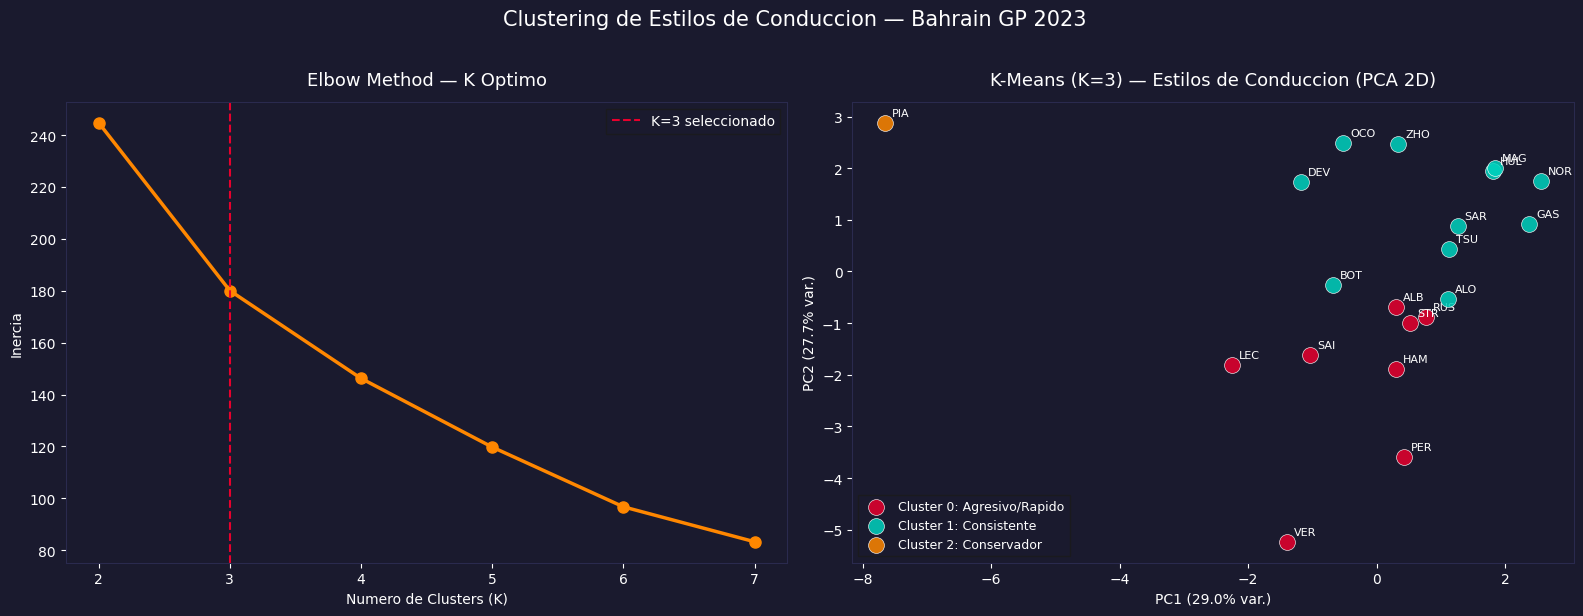


Perfiles de cluster:
  Cluster 0 (Agresivo/Rapido): ALB, HAM, LEC, PER, RUS, SAI, STR, VER
  Cluster 1 (Consistente): ALO, BOT, DEV, GAS, HUL, MAG, NOR, OCO, SAR, TSU, ZHO
  Cluster 2 (Conservador): PIA

PCA Loadings (contribucion al PC1):
                PC1     PC2
LapTimeS_std 0.3970  0.2320
SpeedI2_mean 0.3770  0.0640
Sector3S_std 0.3750  0.2160
Sector2S_std 0.3600  0.2780
Sector1S_std 0.3220  0.2940
SpeedI1_mean 0.1700 -0.2550
SpeedI1_std  0.1270  0.1260
SpeedI2_std  0.0890 -0.1160


In [9]:
# ============================================================
# SECCIÓN 6: K-MEANS CLUSTERING + PCA
# ============================================================

print("Preparando features para clustering por piloto...")

feature_cols = [c for c in ['LapTimeS','Sector1S','Sector2S','Sector3S',
                              'SpeedI1','SpeedI2','SpeedFL','SpeedST']
                if c in valid_laps.columns]

driver_profile = (valid_laps.groupby('Driver')[feature_cols]
                  .agg(['mean','std'])
                  .fillna(0))
driver_profile.columns = ['_'.join(c) for c in driver_profile.columns]
driver_profile = driver_profile.reset_index()

drivers_list = driver_profile['Driver'].values
X = driver_profile.drop('Driver', axis=1).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
K_range  = range(2, min(8, len(drivers_list)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=COLORS['bg'])

ax1 = axes[0]
ax1.set_facecolor(COLORS['bg'])
ax1.plot(list(K_range), inertias, 'o-', color=COLORS['accent'], lw=2.5, ms=8)
ax1.axvline(3, color=COLORS['primary'], ls='--', lw=1.5, label='K=3 seleccionado')
ax1.set_title('Elbow Method — K Optimo', color='white', fontsize=13)
ax1.set_xlabel('Numero de Clusters (K)', color='white')
ax1.set_ylabel('Inercia', color='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_color(COLORS['grid'])
ax1.legend(facecolor=COLORS['bg'], labelcolor='white')

# K=3 + PCA
K_BEST = 3
kmeans  = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_
print(f"PCA varianza explicada: PC1={exp_var[0]:.1%}, PC2={exp_var[1]:.1%}, "
      f"Total={sum(exp_var):.1%}")

ax2 = axes[1]
ax2.set_facecolor(COLORS['bg'])
cluster_colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]
cluster_names  = ['Agresivo/Rapido', 'Consistente', 'Conservador']

for k in range(K_BEST):
    mask = clusters == k
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=cluster_colors[k], s=130, alpha=0.85,
                edgecolors='white', lw=0.5,
                label=f'Cluster {k}: {cluster_names[k]}', zorder=3)
    for i, drv in enumerate(drivers_list):
        if mask[i]:
            ax2.annotate(drv, (X_pca[i, 0], X_pca[i, 1]),
                         xytext=(5, 5), textcoords='offset points',
                         color='white', fontsize=8)

ax2.set_title(f'K-Means (K={K_BEST}) — Estilos de Conduccion (PCA 2D)',
              color='white', fontsize=13)
ax2.set_xlabel(f'PC1 ({exp_var[0]:.1%} var.)', color='white')
ax2.set_ylabel(f'PC2 ({exp_var[1]:.1%} var.)', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color(COLORS['grid'])
ax2.legend(facecolor=COLORS['bg'], labelcolor='white', fontsize=9)

plt.suptitle('Clustering de Estilos de Conduccion — Bahrain GP 2023',
             color='white', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('./ml_01_clustering.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()

driver_profile['Cluster'] = clusters
print("\nPerfiles de cluster:")
for k in range(K_BEST):
    members = driver_profile[driver_profile['Cluster'] == k]['Driver'].tolist()
    print(f"  Cluster {k} ({cluster_names[k]}): {', '.join(members)}")

print("\nPCA Loadings (contribucion al PC1):")
feat_names_pca = driver_profile.drop(['Driver','Cluster'], axis=1).columns.tolist()
loadings = pd.DataFrame(pca.components_.T, index=feat_names_pca, columns=['PC1','PC2'])
print(loadings.sort_values('PC1', ascending=False).head(8).round(3))

---
## Sección 7 · Algoritmos — Regresión: Predicción de Tiempos de Vuelta
**Objetivo:** Predecir el tiempo de vuelta en función de edad del neumático, compuesto y stint.


Preparando dataset de regresion...
  Train: 731  |  Test: 183
  Regresion Lineal        MAE=0.5783s  R2=0.6632  CV-R2=0.4857
  Ridge (a=1.0)           MAE=0.5783s  R2=0.6632  CV-R2=0.4868
  Random Forest           MAE=0.4760s  R2=0.7277  CV-R2=0.5726


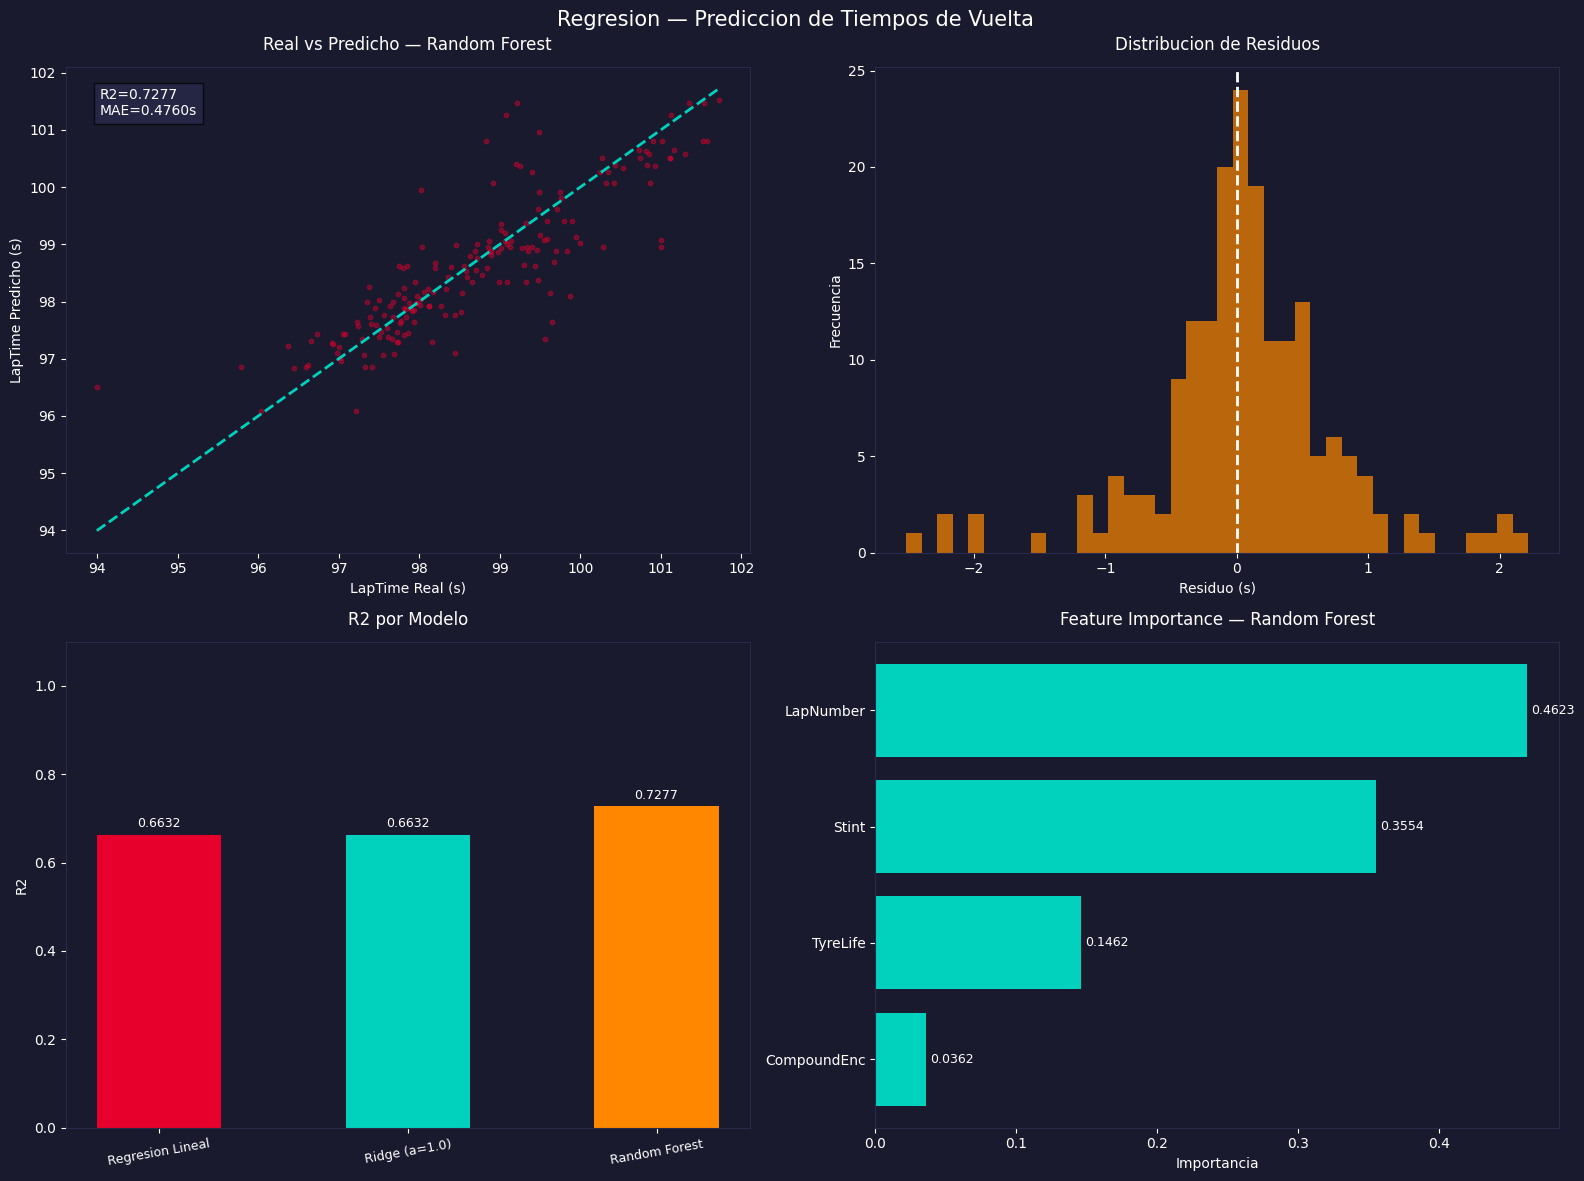


Prediccion de degradacion por compuesto (TyreLife 1 a 30):
  HARD    : 100.483s (v1) -> 100.621s (v30)  [delta=+0.138s]
  MEDIUM  : 100.404s (v1) -> 100.625s (v30)  [delta=+0.221s]
  SOFT    : 99.878s (v1) -> 98.959s (v30)  [delta=-0.919s]


In [9]:
# ============================================================
# SECCIÓN 7: REGRESIÓN (PREDICCIÓN LAPTIME)
# ============================================================

print("Preparando dataset de regresion...")

le = LabelEncoder()
reg_df = valid_laps[['LapTimeS','TyreLife','Stint','LapNumber','Compound']].dropna().copy()
reg_df['CompoundEnc'] = le.fit_transform(reg_df['Compound'])

feature_names = ['TyreLife','Stint','LapNumber','CompoundEnc']
X_reg = reg_df[feature_names].values
y_reg = reg_df['LapTimeS'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)
print(f"  Train: {len(X_train):,}  |  Test: {len(X_test):,}")

models = {
    'Regresion Lineal': LinearRegression(),
    'Ridge (a=1.0)':    Ridge(alpha=1.0),
    'Random Forest':    RandomForestRegressor(n_estimators=100, random_state=42,
                                              max_depth=8, n_jobs=-1),
}
results_reg = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    cv  = cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')
    results_reg[name] = {'model': model, 'y_pred': y_pred, 'MAE': mae, 'R2': r2}
    print(f"  {name:22s}  MAE={mae:.4f}s  R2={r2:.4f}  CV-R2={cv.mean():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=COLORS['bg'])
fig.suptitle('Regresion — Prediccion de Tiempos de Vuelta', color='white', fontsize=15)

# Real vs Predicted
best_name = max(results_reg, key=lambda k: results_reg[k]['R2'])
best = results_reg[best_name]
ax1 = axes[0][0]
ax1.set_facecolor(COLORS['bg'])
ax1.scatter(y_test, best['y_pred'], alpha=0.4, s=10, color=COLORS['primary'])
lims = [min(y_test.min(), best['y_pred'].min()),
        max(y_test.max(), best['y_pred'].max())]
ax1.plot(lims, lims, '--', color=COLORS['secondary'], lw=2, label='Ideal')
ax1.set_title(f'Real vs Predicho — {best_name}', color='white', fontsize=12)
ax1.set_xlabel('LapTime Real (s)', color='white')
ax1.set_ylabel('LapTime Predicho (s)', color='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_color(COLORS['grid'])
ax1.text(0.05, 0.9, f"R2={best['R2']:.4f}\nMAE={best['MAE']:.4f}s",
         transform=ax1.transAxes, color='white', fontsize=10,
         bbox=dict(facecolor=COLORS['grid'], alpha=0.7))

# Residuos
ax2 = axes[0][1]
ax2.set_facecolor(COLORS['bg'])
residuals = y_test - best['y_pred']
ax2.hist(residuals, bins=40, color=COLORS['accent'], alpha=0.7, edgecolor='none')
ax2.axvline(0, color='white', lw=2, ls='--')
ax2.set_title('Distribucion de Residuos', color='white', fontsize=12)
ax2.set_xlabel('Residuo (s)', color='white')
ax2.set_ylabel('Frecuencia', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color(COLORS['grid'])

# R2 por modelo
ax3 = axes[1][0]
ax3.set_facecolor(COLORS['bg'])
mnames = list(results_reg.keys())
r2vals = [results_reg[m]['R2'] for m in mnames]
bars = ax3.bar(range(len(mnames)), r2vals,
               color=[COLORS['primary'], COLORS['secondary'], COLORS['accent']],
               edgecolor='none', width=0.5)
ax3.bar_label(bars, fmt='%.4f', padding=3, color='white', fontsize=9)
ax3.set_xticks(range(len(mnames)))
ax3.set_xticklabels(mnames, color='white', fontsize=9, rotation=10)
ax3.set_title('R2 por Modelo', color='white', fontsize=12)
ax3.set_ylabel('R2', color='white')
ax3.set_ylim(0, 1.1)
ax3.tick_params(colors='white')
ax3.spines[:].set_color(COLORS['grid'])

# Feature importance
ax4 = axes[1][1]
ax4.set_facecolor(COLORS['bg'])
rf_model = results_reg['Random Forest']['model']
fi = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()
bars4 = ax4.barh(fi.index, fi.values, color=COLORS['secondary'], edgecolor='none')
ax4.bar_label(bars4, fmt='%.4f', padding=3, color='white', fontsize=9)
ax4.set_title('Feature Importance — Random Forest', color='white', fontsize=12)
ax4.set_xlabel('Importancia', color='white')
ax4.tick_params(colors='white')
ax4.spines[:].set_color(COLORS['grid'])

plt.tight_layout()
plt.savefig('./ml_02_regression.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()

print("\nPrediccion de degradacion por compuesto (TyreLife 1 a 30):")
tyre_range = np.arange(1, 31)
for comp_idx, comp_name in enumerate(le.classes_):
    if comp_name not in ['SOFT','MEDIUM','HARD']:
        continue
    sample = np.column_stack([tyre_range, np.ones(30),
                               np.full(30, 25), np.full(30, comp_idx)])
    pred = rf_model.predict(sample)
    print(f"  {comp_name:8s}: {pred[0]:.3f}s (v1) -> {pred[-1]:.3f}s (v30)  "
          f"[delta={pred[-1]-pred[0]:+.3f}s]")

---
## Sección 8 · Algoritmos — Clasificación: Detección de Oportunidades de Undercut
**Objetivo:** Clasificar si una vuelta es candidata a undercut.


Creando dataset de clasificacion...
  Clase 0 (no undercut): 651  |  Clase 1 (undercut): 194
  Balance: 23.0% positivos

Decision Tree:
              precision    recall  f1-score   support

 No Undercut       1.00      1.00      1.00       130
    Undercut       1.00      1.00      1.00        39

    accuracy                           1.00       169
   macro avg       1.00      1.00      1.00       169
weighted avg       1.00      1.00      1.00       169

  CV F1-score: 1.0000 +/- 0.0000

Random Forest:
              precision    recall  f1-score   support

 No Undercut       1.00      1.00      1.00       130
    Undercut       1.00      1.00      1.00        39

    accuracy                           1.00       169
   macro avg       1.00      1.00      1.00       169
weighted avg       1.00      1.00      1.00       169

  CV F1-score: 1.0000 +/- 0.0000


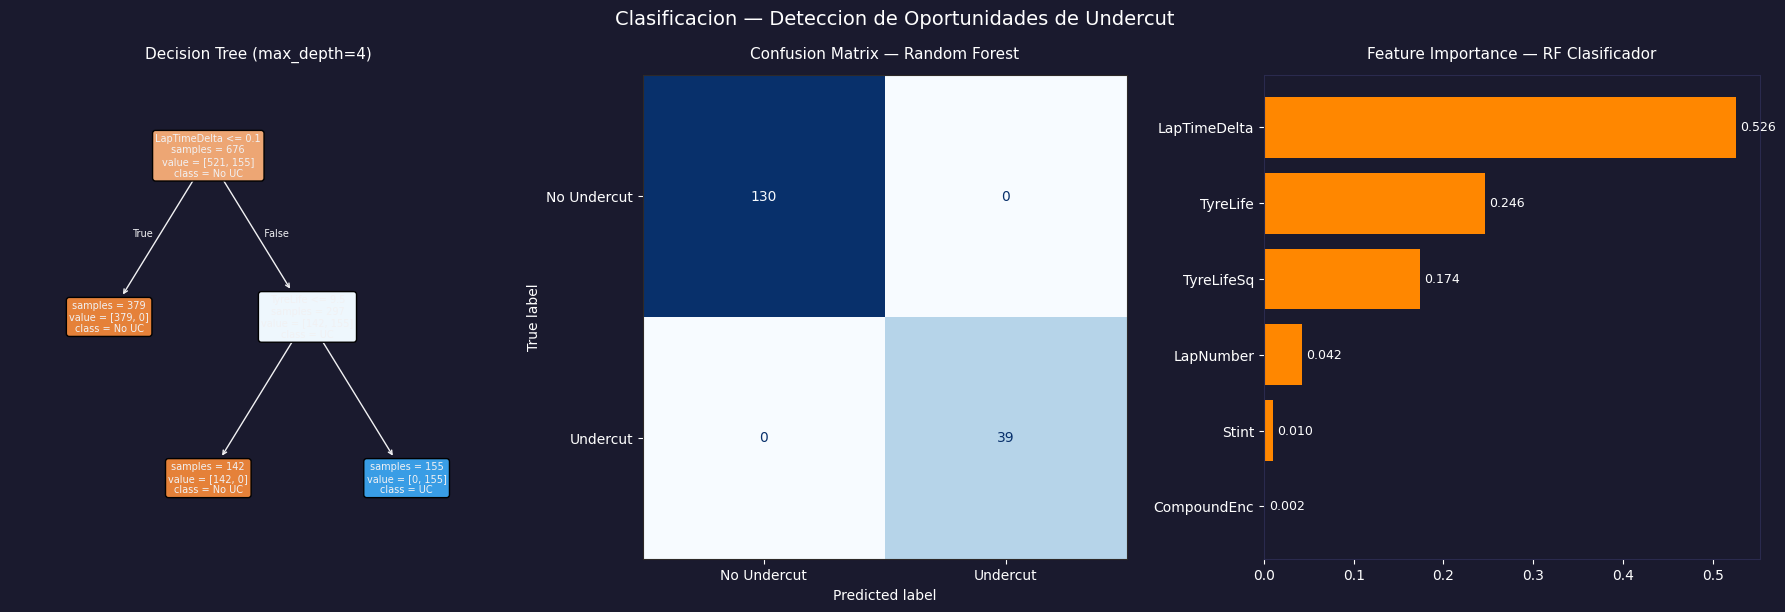


Reglas del Decision Tree:
|--- LapTimeDelta <= 0.10
|   |--- class: 0
|--- LapTimeDelta >  0.10
|   |--- TyreLife <= 9.50
|   |   |--- class: 0
|   |--- TyreLife >  9.50
|   |   |--- class: 1



In [10]:
# ============================================================
# SECCIÓN 8: CLASIFICACIÓN — UNDERCUT DETECTOR
# ============================================================

print("Creando dataset de clasificacion...")

clf_df = valid_laps[['Driver','LapNumber','LapTimeS','TyreLife',
                       'Stint','Compound']].dropna().copy()
clf_df = clf_df.sort_values(['Driver','LapNumber'])
clf_df['LapTimeDelta'] = clf_df.groupby(['Driver','Stint'])['LapTimeS'].diff()
clf_df['TyreLifeSq']   = clf_df['TyreLife'] ** 2

tyre_median = clf_df['TyreLife'].median()
clf_df['undercut_opp'] = (
    (clf_df['TyreLife'] > tyre_median) &
    (clf_df['LapTimeDelta'] > 0.1)
).astype(int)

le_clf = LabelEncoder()
clf_df['CompoundEnc'] = le_clf.fit_transform(clf_df['Compound'])
clf_df = clf_df.dropna()

X_clf = clf_df[['TyreLife','TyreLifeSq','LapTimeDelta',
                 'Stint','LapNumber','CompoundEnc']].values
y_clf = clf_df['undercut_opp'].values
feat_names_clf = ['TyreLife','TyreLifeSq','LapTimeDelta','Stint','LapNumber','CompoundEnc']

print(f"  Clase 0 (no undercut): {(y_clf==0).sum():,}  |  Clase 1 (undercut): {(y_clf==1).sum():,}")
print(f"  Balance: {y_clf.mean():.1%} positivos")

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

dt  = DecisionTreeClassifier(max_depth=4, random_state=42)
rfc = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)

for name, clf in [('Decision Tree', dt), ('Random Forest', rfc)]:
    clf.fit(X_c_train, y_c_train)
    y_pred_c = clf.predict(X_c_test)
    cv_scores = cross_val_score(clf, X_clf, y_clf, cv=5, scoring='f1')
    print(f"\n{name}:")
    print(classification_report(y_c_test, y_pred_c,
          target_names=['No Undercut','Undercut']))
    print(f"  CV F1-score: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=COLORS['bg'])
fig.suptitle('Clasificacion — Deteccion de Oportunidades de Undercut',
             color='white', fontsize=14)

# Arbol de decision
plot_tree(dt, feature_names=feat_names_clf,
          class_names=['No UC','UC'], filled=True, rounded=True,
          ax=axes[0], impurity=False, fontsize=7)
axes[0].set_title('Decision Tree (max_depth=4)', color='white', fontsize=11)

# Confusion matrix RF
y_pred_rf = rfc.predict(X_c_test)
cm = confusion_matrix(y_c_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Undercut','Undercut'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix — Random Forest', color='white', fontsize=11)
axes[1].tick_params(colors='white')
axes[1].xaxis.label.set_color('white')
axes[1].yaxis.label.set_color('white')

# Feature importance
fi_clf = pd.Series(rfc.feature_importances_, index=feat_names_clf).sort_values()
bars_fi = axes[2].barh(fi_clf.index, fi_clf.values,
                        color=COLORS['accent'], edgecolor='none')
axes[2].set_facecolor(COLORS['bg'])
axes[2].bar_label(bars_fi, fmt='%.3f', padding=3, color='white', fontsize=9)
axes[2].set_title('Feature Importance — RF Clasificador', color='white', fontsize=11)
axes[2].tick_params(colors='white')
axes[2].spines[:].set_color(COLORS['grid'])

plt.tight_layout()
plt.savefig('./ml_03_classification.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()

print("\nReglas del Decision Tree:")
print(export_text(dt, feature_names=feat_names_clf))

---
## Sección 9 · Algoritmos — Detección de Anomalías en Telemetría
**Objetivo:** Identificar vueltas anómalas (SC, accidentes, problemas mecánicos).


Preparando datos para deteccion de anomalias...
  Outliers Z-Score (|z|>3):      40  (6.2%)
  Outliers Isolation Forest:     32  (5.0%)
  Acuerdo entre ambos metodos:   29


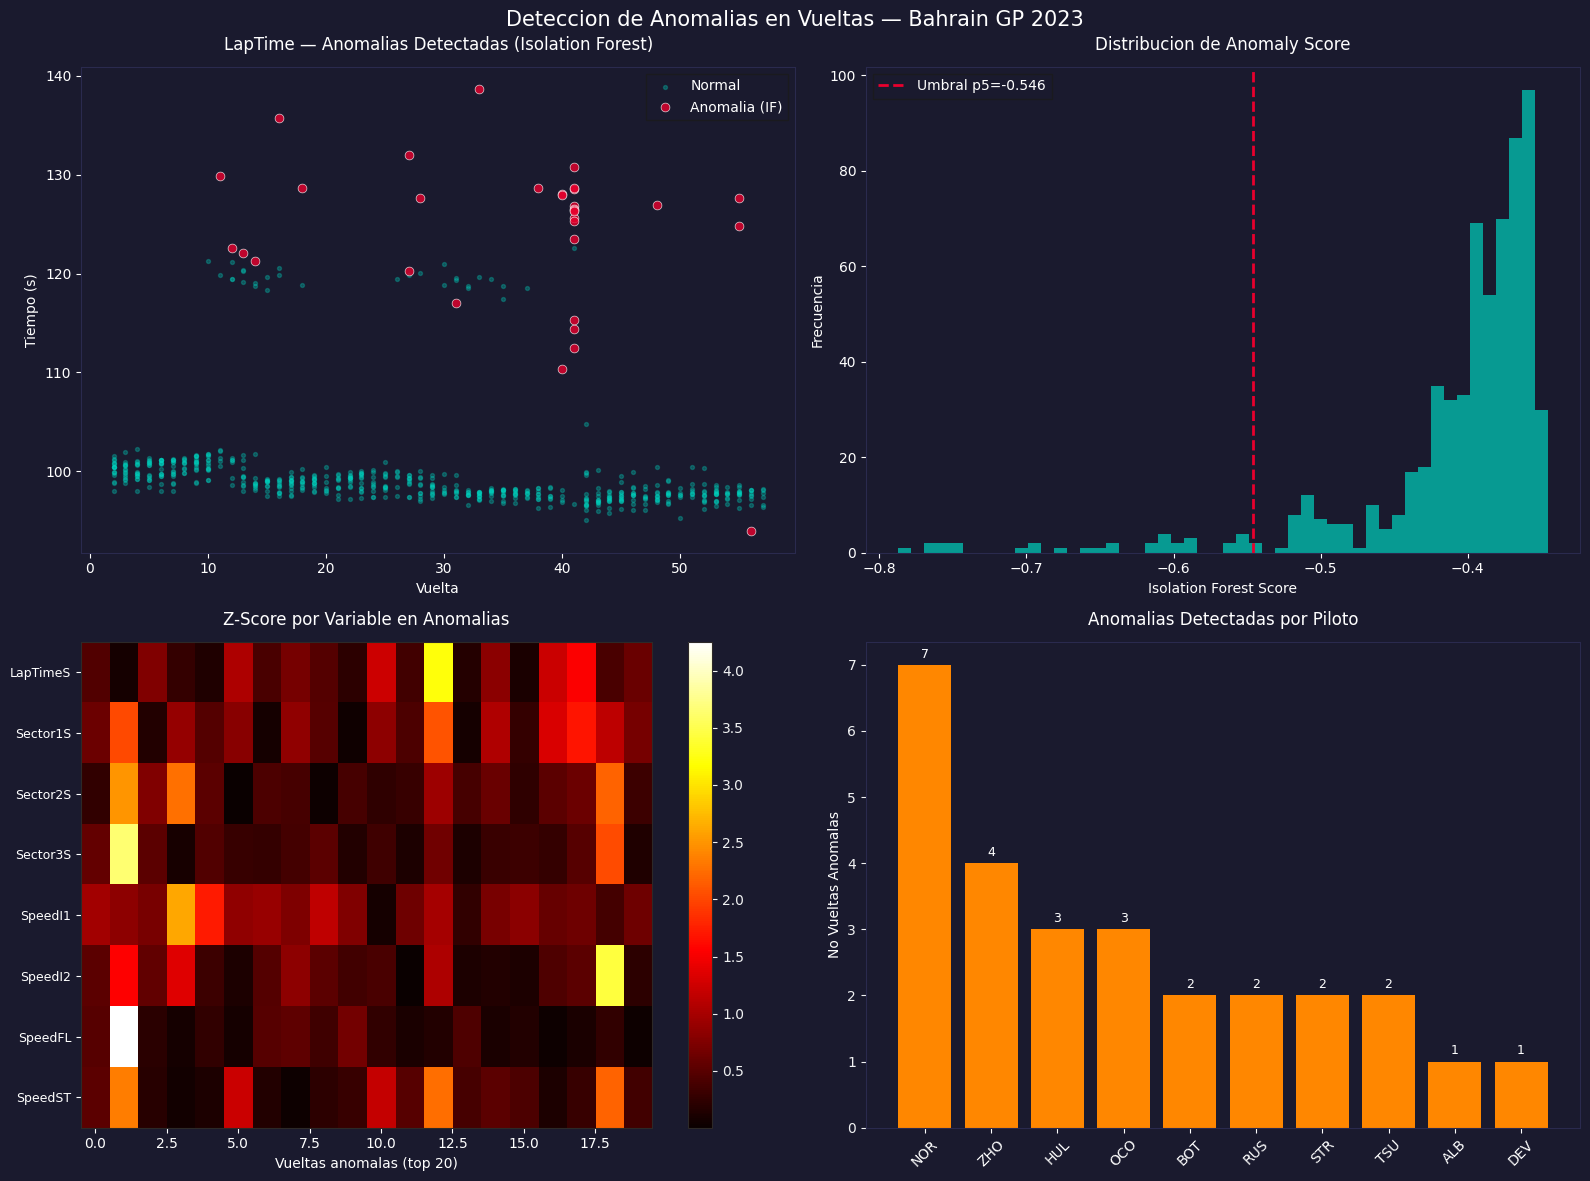


Top 10 vueltas mas anomalas (menor IF score):
Driver  LapNumber  LapTimeS  if_score  z_outlier
   PER    41.0000  123.5220   -0.7870       True
   NOR    40.0000  127.9700   -0.7676       True
   SAI    41.0000  126.4360   -0.7611       True
   HAM    41.0000  126.4910   -0.7570       True
   OCO    40.0000  128.0230   -0.7563       True
   STR    41.0000  126.8090   -0.7511       True
   RUS    41.0000  126.2930   -0.7435       True
   BOT    41.0000  115.2810   -0.7064       True
   GAS    41.0000  128.5440   -0.6974       True
   ALB    41.0000  128.6590   -0.6939       True


In [11]:
# ============================================================
# SECCIÓN 9: DETECCIÓN DE ANOMALÍAS — ISOLATION FOREST + Z-SCORE
# ============================================================

print("Preparando datos para deteccion de anomalias...")

anom_cols = [c for c in ['LapTimeS','Sector1S','Sector2S','Sector3S',
                           'SpeedI1','SpeedI2','SpeedFL','SpeedST']
             if c in laps.columns]
anom_df = laps[['Driver','LapNumber'] + anom_cols].dropna().copy()
X_anom  = anom_df[anom_cols].values

scaler_anom = StandardScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

# Z-Score
z_scores  = np.abs(stats.zscore(X_anom_scaled, axis=0))
z_outlier = (z_scores > 3).any(axis=1)

# Isolation Forest
iforest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
if_labels = iforest.fit_predict(X_anom_scaled)
if_outlier = if_labels == -1
if_scores  = iforest.score_samples(X_anom_scaled)

anom_df = anom_df.copy()
anom_df['z_outlier']    = z_outlier
anom_df['if_outlier']   = if_outlier
anom_df['if_score']     = if_scores
anom_df['both_outlier'] = z_outlier & if_outlier

print(f"  Outliers Z-Score (|z|>3):    {z_outlier.sum():>4}  ({z_outlier.mean():.1%})")
print(f"  Outliers Isolation Forest:   {if_outlier.sum():>4}  ({if_outlier.mean():.1%})")
print(f"  Acuerdo entre ambos metodos: {anom_df['both_outlier'].sum():>4}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=COLORS['bg'])
fig.suptitle('Deteccion de Anomalias en Vueltas — Bahrain GP 2023',
             color='white', fontsize=15)

# LapTime con outliers
ax1 = axes[0][0]
ax1.set_facecolor(COLORS['bg'])
normal = anom_df[~anom_df['if_outlier']]
anomal = anom_df[anom_df['if_outlier']]
ax1.scatter(normal['LapNumber'], normal['LapTimeS'],
            s=8, alpha=0.3, color=COLORS['secondary'], label='Normal')
ax1.scatter(anomal['LapNumber'], anomal['LapTimeS'],
            s=40, alpha=0.8, color=COLORS['primary'],
            edgecolors='white', lw=0.5, zorder=5, label='Anomalia (IF)')
ax1.set_title('LapTime — Anomalias Detectadas (Isolation Forest)',
              color='white', fontsize=12)
ax1.set_xlabel('Vuelta', color='white')
ax1.set_ylabel('Tiempo (s)', color='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_color(COLORS['grid'])
ax1.legend(facecolor=COLORS['bg'], labelcolor='white')

# Anomaly score dist
ax2 = axes[0][1]
ax2.set_facecolor(COLORS['bg'])
ax2.hist(if_scores, bins=50, color=COLORS['secondary'], alpha=0.7, edgecolor='none')
thresh = np.percentile(if_scores, 5)
ax2.axvline(thresh, color=COLORS['primary'], lw=2, ls='--',
            label=f'Umbral p5={thresh:.3f}')
ax2.set_title('Distribucion de Anomaly Score', color='white', fontsize=12)
ax2.set_xlabel('Isolation Forest Score', color='white')
ax2.set_ylabel('Frecuencia', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_color(COLORS['grid'])
ax2.legend(facecolor=COLORS['bg'], labelcolor='white')

# Heatmap Z-scores anomalias
ax3 = axes[1][0]
ax3.set_facecolor(COLORS['bg'])
top_anom = anom_df[anom_df['if_outlier']].head(20)
if not top_anom.empty:
    z_heat = np.abs(stats.zscore(top_anom[anom_cols].fillna(0).values, axis=0))
    im = ax3.imshow(z_heat.T, aspect='auto', cmap='hot', interpolation='nearest')
    ax3.set_yticks(range(len(anom_cols)))
    ax3.set_yticklabels(anom_cols, color='white', fontsize=9)
    ax3.set_xlabel('Vueltas anomalas (top 20)', color='white')
    ax3.set_title('Z-Score por Variable en Anomalias', color='white', fontsize=12)
    ax3.tick_params(colors='white')
    plt.colorbar(im, ax=ax3)

# Anomalias por piloto
ax4 = axes[1][1]
ax4.set_facecolor(COLORS['bg'])
anom_by_driver = (anom_df[anom_df['if_outlier']].groupby('Driver').size()
                  .sort_values(ascending=False).head(10))
bars = ax4.bar(anom_by_driver.index, anom_by_driver.values,
               color=COLORS['accent'], edgecolor='none')
ax4.bar_label(bars, padding=3, color='white', fontsize=9)
ax4.set_title('Anomalias Detectadas por Piloto', color='white', fontsize=12)
ax4.set_ylabel('No Vueltas Anomalas', color='white')
ax4.tick_params(colors='white', axis='x', rotation=45)
ax4.spines[:].set_color(COLORS['grid'])

plt.tight_layout()
plt.savefig('./ml_04_anomalies.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()

print("\nTop 10 vueltas mas anomalas (menor IF score):")
top10 = anom_df.nsmallest(10, 'if_score')[
    ['Driver','LapNumber','LapTimeS','if_score','z_outlier']].reset_index(drop=True)
print(top10.to_string(index=False))